In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import math
import scipy.stats as stats
from ucimlrepo import fetch_ucirepo
import math
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from keras import layers
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier


statlog_heart = fetch_ucirepo(id=145)

df = statlog_heart.data.features.copy()
df['target'] = statlog_heart.data.targets

print(df.head())

    age  sex  chest-pain  rest-bp  serum-chol  fasting-blood-sugar  \
0  70.0  1.0         4.0    130.0       322.0                  0.0   
1  67.0  0.0         3.0    115.0       564.0                  0.0   
2  57.0  1.0         2.0    124.0       261.0                  0.0   
3  64.0  1.0         4.0    128.0       263.0                  0.0   
4  74.0  0.0         2.0    120.0       269.0                  0.0   

   electrocardiographic  max-heart-rate  angina  oldpeak  slope  \
0                   2.0           109.0     0.0      2.4    2.0   
1                   2.0           160.0     0.0      1.6    2.0   
2                   0.0           141.0     0.0      0.3    1.0   
3                   0.0           105.0     1.0      0.2    2.0   
4                   2.0           121.0     1.0      0.2    1.0   

   major-vessels  thal  target  
0            3.0   3.0       2  
1            0.0   7.0       1  
2            0.0   7.0       2  
3            1.0   7.0       1  
4          

# Функция для вывода статистики

In [40]:
# Функция для построения гистограммы распределения признаков и вывода стастистики
def print_stats(dataframe, feature_name, k):
    plt.hist(dataframe[feature_name], bins=k, edgecolor='black')
    plt.title(f'Распределение признака {feature_name}')
    plt.xlabel(feature_name)
    plt.ylabel('Частота')

    shapiro_test = stats.shapiro(dataframe[feature_name])
    dagostino_test = stats.normaltest(dataframe[feature_name])
    ks_test = stats.kstest(
        dataframe[feature_name],
        'norm',
        args=(dataframe[feature_name].mean(), dataframe[feature_name].std())
    )

    def interpret_pvalue(p):
        if p > 0.05:
            return "Нормальное"
        elif p > 0.01:
            return "Близко к нормальному"
        else:
            return "Далеко от нормального"

    # Дескриптивный анализ
    print (
        f"Статистика для признака {feature_name}:\n"
        f"--------------------------|-------------------------------------------\n"
        f"Среднее:                  | {dataframe[feature_name].mean()}\n"
        f"Медиана:                  | {dataframe[feature_name].median()}\n"
        f"Мода:                     | {dataframe[feature_name].mode()[0]}\n"
        f"Минимум:                  | {dataframe[feature_name].min()}\n"
        f"Максимум:                 | {dataframe[feature_name].max()}\n"
        f"Размах:                   | {dataframe[feature_name].max() - dataframe[feature_name].min()}\n"
        f"Стандартное отклонение:   | {dataframe[feature_name].std()}\n"
        f"Дисперсия:                | {dataframe[feature_name].var()}\n"
        f"Асимметрия:               | {dataframe[feature_name].skew()}\n"
        f"Эксцесс:                  | {dataframe[feature_name].kurtosis()}\n"
        f"Квантили (25%, 50%, 75%): | {dataframe[feature_name].quantile([0.25, 0.5, 0.75]).to_dict()}\n"
        f"Оценка нормальности распредления:\n"
        f"--------------------------|-------------------------------------------\n"
        f"Шапиро-Уилк:              | p={shapiro_test.pvalue:.3e} → {interpret_pvalue(shapiro_test.pvalue)}\n"
        f"Д'Агостино-Пиросона:      | p={dagostino_test.pvalue:.3e} → {interpret_pvalue(dagostino_test.pvalue)}\n"
        f"Колмагорова-Смирнова      | p={ks_test.pvalue:.3e} → {interpret_pvalue(ks_test.pvalue)}\n"
    )



n = df.shape[0]
k = int(math.ceil(1 + math.log2(n)))
print(f"Количество записей: {n}")
print(f"Количество интервалов по формуле Стержиса: {k}")

Количество записей: 270
Количество интервалов по формуле Стержиса: 10


# age

Статистика для признака age:
--------------------------|-------------------------------------------
Среднее:                  | 54.43333333333333
Медиана:                  | 55.0
Мода:                     | 54.0
Минимум:                  | 29.0
Максимум:                 | 77.0
Размах:                   | 48.0
Стандартное отклонение:   | 9.109066523898207
Дисперсия:                | 82.97509293680295
Асимметрия:               | -0.16361522733654557
Эксцесс:                  | -0.5448153930171342
Квантили (25%, 50%, 75%): | {0.25: 48.0, 0.5: 55.0, 0.75: 61.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=2.765e-02 → Близко к нормальному
Д'Агостино-Пиросона:      | p=2.763e-02 → Близко к нормальному
Колмагорова-Смирнова      | p=1.755e-01 → Нормальное



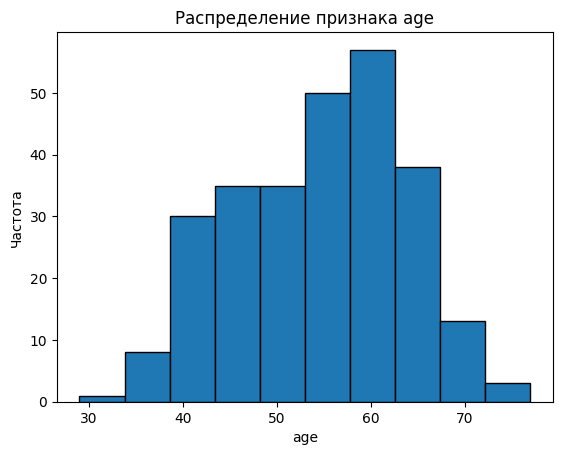

In [41]:
print_stats(df, "age", k)

# rest-bp

Статистика для признака rest-bp:
--------------------------|-------------------------------------------
Среднее:                  | 131.34444444444443
Медиана:                  | 130.0
Мода:                     | 120.0
Минимум:                  | 94.0
Максимум:                 | 200.0
Размах:                   | 106.0
Стандартное отклонение:   | 17.861608292800856
Дисперсия:                | 319.03705080545234
Асимметрия:               | 0.7226180070438306
Эксцесс:                  | 0.9230967359120847
Квантили (25%, 50%, 75%): | {0.25: 120.0, 0.5: 130.0, 0.75: 140.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=3.739e-06 → Далеко от нормального
Д'Агостино-Пиросона:      | p=2.198e-06 → Далеко от нормального
Колмагорова-Смирнова      | p=8.052e-03 → Далеко от нормального



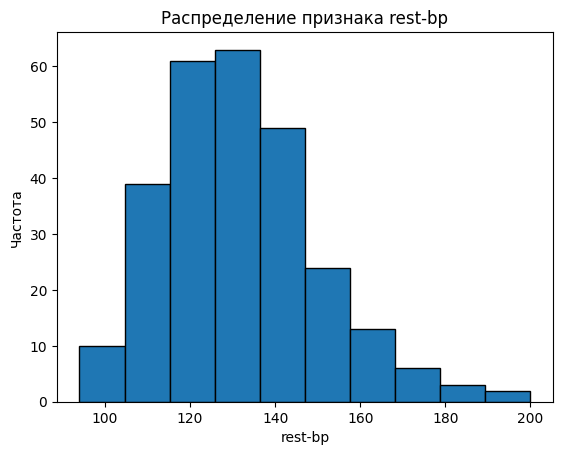

In [42]:
print_stats(df, "rest-bp", k)

# serum-chol

Статистика для признака serum-chol:
--------------------------|-------------------------------------------
Среднее:                  | 249.65925925925927
Медиана:                  | 245.0
Мода:                     | 234.0
Минимум:                  | 126.0
Максимум:                 | 564.0
Размах:                   | 438.0
Стандартное отклонение:   | 51.68623711643124
Дисперсия:                | 2671.4671072559545
Асимметрия:               | 1.1837208885656836
Эксцесс:                  | 4.895598990181746
Квантили (25%, 50%, 75%): | {0.25: 213.0, 0.5: 245.0, 0.75: 280.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=1.079e-08 → Далеко от нормального
Д'Агостино-Пиросона:      | p=4.539e-18 → Далеко от нормального
Колмагорова-Смирнова      | p=4.696e-01 → Нормальное



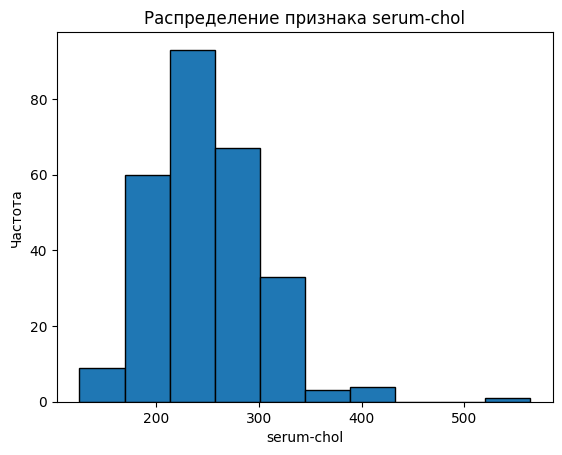

In [43]:
print_stats(df, "serum-chol", k)

# max-heart-rate

Статистика для признака max-heart-rate:
--------------------------|-------------------------------------------
Среднее:                  | 149.67777777777778
Медиана:                  | 153.5
Мода:                     | 162.0
Минимум:                  | 71.0
Максимум:                 | 202.0
Размах:                   | 131.0
Стандартное отклонение:   | 23.165716775120096
Дисперсия:                | 536.6504337050806
Асимметрия:               | -0.5277366828794363
Эксцесс:                  | -0.10307188534537648
Квантили (25%, 50%, 75%): | {0.25: 133.0, 0.5: 153.5, 0.75: 166.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=1.450e-04 → Далеко от нормального
Д'Агостино-Пиросона:      | p=2.847e-03 → Далеко от нормального
Колмагорова-Смирнова      | p=7.147e-02 → Нормальное



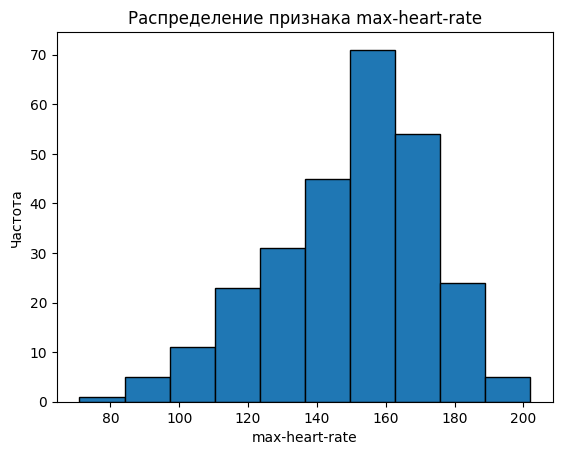

In [44]:
print_stats(df, "max-heart-rate", k)

# oldpeak

Статистика для признака oldpeak:
--------------------------|-------------------------------------------
Среднее:                  | 1.05
Медиана:                  | 0.8
Мода:                     | 0.0
Минимум:                  | 0.0
Максимум:                 | 6.2
Размах:                   | 6.2
Стандартное отклонение:   | 1.1452098393779973
Дисперсия:                | 1.3115055762081784
Асимметрия:               | 1.2628932110432118
Эксцесс:                  | 1.7593165294222333
Квантили (25%, 50%, 75%): | {0.25: 0.0, 0.5: 0.8, 0.75: 1.6}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=2.103e-15 → Далеко от нормального
Д'Агостино-Пиросона:      | p=5.120e-14 → Далеко от нормального
Колмагорова-Смирнова      | p=4.309e-08 → Далеко от нормального



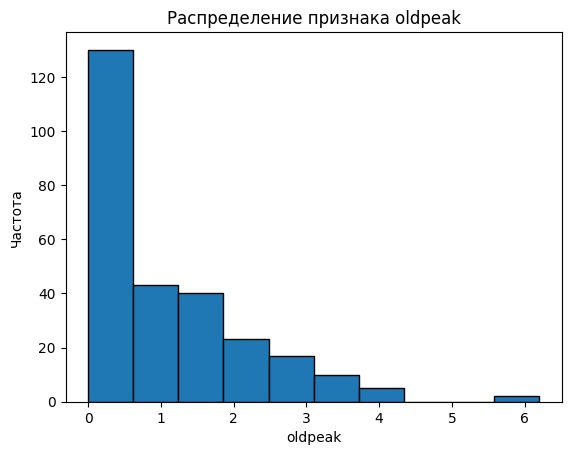

In [45]:
print_stats(df, "oldpeak", k)

# target

Статистика для признака target:
--------------------------|-------------------------------------------
Среднее:                  | 1.4444444444444444
Медиана:                  | 1.0
Мода:                     | 1
Минимум:                  | 1
Максимум:                 | 2
Размах:                   | 1
Стандартное отклонение:   | 0.4978267515886163
Дисперсия:                | 0.24783147459727387
Асимметрия:               | 0.22485794134254491
Эксцесс:                  | -1.9640428475599532
Квантили (25%, 50%, 75%): | {0.25: 1.0, 0.5: 1.0, 0.75: 2.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=1.040e-23 → Далеко от нормального
Д'Агостино-Пиросона:      | p=8.752e-295 → Далеко от нормального
Колмагорова-Смирнова      | p=1.372e-33 → Далеко от нормального



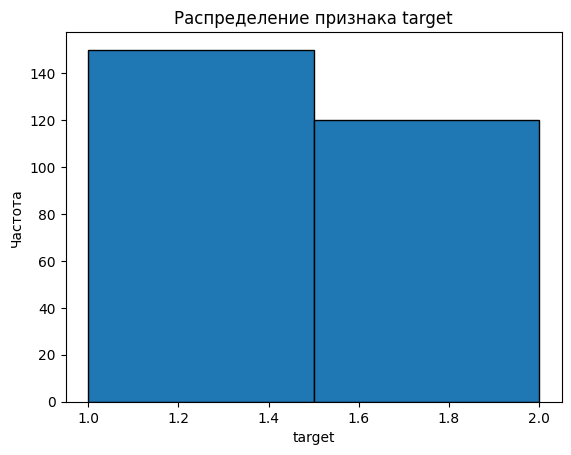

In [46]:
print_stats(df, "target", 2)

# Нейронные сети

## Подготовка данных

In [47]:
X = df.drop('target', axis=1) # Все кроме целевой переменной
y = df['target'].map({1: 0, 2: 1}) # Целевая переменная + преобразование в бинарную (1 - нет болезни, 0 - есть болезнь)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Разделение на обучающую и тестовую выборки

# Стандартизация признаков
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



## Построение и компиляция модели

In [48]:
num_classes = len(np.unique(y))

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,010 (3.95 KB)

 Trainable params: 1,010 (3.95 KB)

 Non-trainable params: 0 (0.00 B)

## Обучение модели

In [49]:
history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=60,
    batch_size=16,
    verbose=1
)

Epoch 1/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4372 - loss: 0.7674 - val_accuracy: 0.5758 - val_loss: 0.6743
Epoch 2/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6284 - loss: 0.6662 - val_accuracy: 0.6667 - val_loss: 0.5903
Epoch 3/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7049 - loss: 0.5947 - val_accuracy: 0.7273 - val_loss: 0.5368
Epoch 4/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7432 - loss: 0.5494 - val_accuracy: 0.7273 - val_loss: 0.4971
Epoch 5/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7760 - loss: 0.5069 - val_accuracy: 0.7273 - val_loss: 0.4686
Epoch 6/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7923 - loss: 0.4760 - val_accuracy: 0.7273 - val_loss: 0.4500
Epoch 7/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8087 - loss: 0.4481 - val_accuracy: 0.7576 - val_loss: 0.4340
Epoch 8/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8197 - loss: 0.4244 - val_accuracy: 0.7576 - val_loss

## Оценка и интерпретация результатов

In [50]:
# Оценка на тестовой выборке
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.3f}")

# Предсказания и метрики
y_pred_probs = model.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Test accuracy: 0.870
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Accuracy: 0.8703703703703703
Classification report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.90        33
           1       0.85      0.81      0.83        21

    accuracy                           0.87        54
   macro avg       0.87      0.86      0.86        54
weighted avg       0.87      0.87      0.87        54

Confusion matrix:
 [[30  3]
 [ 4 17]]


# Дерево решений

## Создаём и обучаем модель

In [51]:
clf = DecisionTreeClassifier(random_state=42, max_depth=4)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test) # Получение предсказаний

# Оценка и метрики
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8703703703703703
Classification report:
               precision    recall  f1-score   support

           0       0.82      1.00      0.90        33
           1       1.00      0.67      0.80        21

    accuracy                           0.87        54
   macro avg       0.91      0.83      0.85        54
weighted avg       0.89      0.87      0.86        54

Confusion matrix:
 [[33  0]
 [ 7 14]]


# Изменение параметров

In [54]:
clf_deep = DecisionTreeClassifier(random_state=42, max_depth=8)
clf_deep.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Оценка и метрики
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8703703703703703
Classification report:
               precision    recall  f1-score   support

           0       0.82      1.00      0.90        33
           1       1.00      0.67      0.80        21

    accuracy                           0.87        54
   macro avg       0.91      0.83      0.85        54
weighted avg       0.89      0.87      0.86        54

Confusion matrix:
 [[33  0]
 [ 7 14]]
